In [1]:
TRAIN = '/kaggle/input/datasets/fernando2rad/brain-tumor-12k-mri-images-w-masks-meta-and-bbox/Images_/Images_'

Let's add some code to get image embeddings using ResNeXt; we will use them for both EDA and classification.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 156MB/s]


Let's load up our data. We're going to use the large eight classes rather than the smaller subclasses. We may revisit if the situation warrants.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image


THUMBNAIL_SIZE = (64, 64)

def embed(model, filename: str):
    with Image.open(fp=filename, mode='r') as image:
        return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGBA').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    time_get = arrow.now()
    input_files = list(iglob(pathname=arg))[:200]
    input_files = [item for item in input_files if item.endswith('.jpg')]
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'] )
        for index, input_file in enumerate(tqdm.tqdm(input_files))]
    print('encoded {} rows of {}  in {}'.format(len(result), tag, arrow.now() - time_get))
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*/*/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder) }
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in train_dict.items()]))
print('done in {}'.format(arrow.now() - time_start))

100%|██████████| 55/55 [00:08<00:00,  6.62it/s]


encoded 55 rows of Mesenchymal (Non-Meningothelial Tumors)  in 0:00:08.730937


100%|██████████| 59/59 [00:08<00:00,  6.97it/s]


encoded 59 rows of Germ Cell Tumors  in 0:00:08.835760


100%|██████████| 43/43 [00:06<00:00,  6.98it/s]


encoded 43 rows of Normal  in 0:00:06.673492


100%|██████████| 50/50 [00:07<00:00,  6.99it/s]


encoded 50 rows of Mixed Neuronal and Neuronal-Glial Tumors  in 0:00:08.120601


100%|██████████| 42/42 [00:06<00:00,  6.90it/s]


encoded 42 rows of Gliomas  in 0:00:08.298144


100%|██████████| 48/48 [00:06<00:00,  6.95it/s]


encoded 48 rows of Meningothelial Tumors  in 0:00:07.547328


100%|██████████| 51/51 [00:07<00:00,  6.94it/s]


encoded 51 rows of Nerve Sheath Tumors  in 0:00:08.058760


100%|██████████| 51/51 [00:07<00:00,  6.98it/s]

encoded 51 rows of Embryonic Tumors  in 0:00:07.960636
done in 0:01:04.286482


Are our classes balanced? No, but they're not terribly imbalanced.

In [4]:
train_df['tag'].value_counts(normalize=True).to_frame().T

tag,Germ Cell Tumors,Mesenchymal (Non-Meningothelial Tumors),Nerve Sheath Tumors,Embryonic Tumors,Mixed Neuronal and Neuronal-Glial Tumors,Meningothelial Tumors,Normal,Gliomas
proportion,0.14787,0.137845,0.12782,0.12782,0.125313,0.120301,0.107769,0.105263


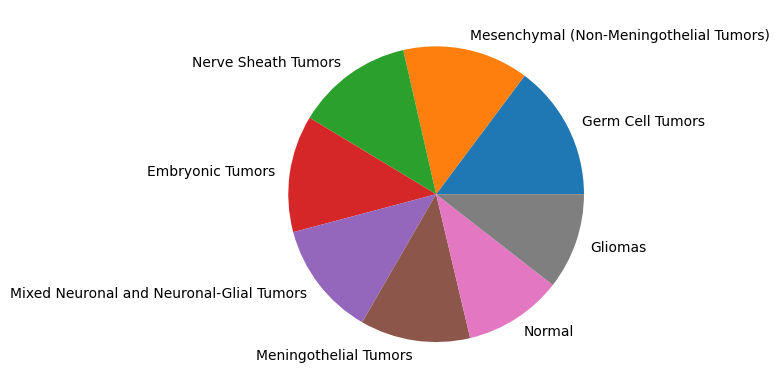

In [5]:
import matplotlib.pyplot as plt

train_df['tag'].value_counts(normalize=False).to_frame().plot.pie(y='count')
plt.ylabel('')
plt.legend().remove()
plt.show()

Let's use TSNE to add x/y coordinates based on our image embeddings.

In [6]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 399 samples in 0.003s...
[t-SNE] Computed neighbors for 399 samples in 0.083s...
[t-SNE] Computed conditional probabilities for sample 399 / 399
[t-SNE] Mean sigma: 4.213050
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.368454
[t-SNE] KL divergence after 1000 iterations: 0.797942


And let's use these x/y coordinates to make an interactive scatter plot.

In [7]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: brain tumors', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

We see some localized clustering, but it isn't tight or especially distinct. This is a messy problem, and we should have modest expectations regarding model accuracy. Let's build a model and see what we get.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_df['value'].apply(pd.Series), train_df['tag'], test_size=0.25, random_state=2026, stratify=train_df['tag'])
logreg = LogisticRegression(max_iter=10000, tol=1e-12).fit(X_train, y_train)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=logreg.predict(X=X_test))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=y_test, y_pred=logreg.predict(X=X_test))))
print(classification_report(y_true=y_test, y_pred=logreg.predict(X=X_test), zero_division=0.0))

model fit in 919 iterations
accuracy: 0.8100
f1: 0.8085
                                          precision    recall  f1-score   support

                        Embryonic Tumors       0.73      0.62      0.67        13
                        Germ Cell Tumors       0.93      0.87      0.90        15
                                 Gliomas       1.00      0.70      0.82        10
                   Meningothelial Tumors       0.75      0.75      0.75        12
 Mesenchymal (Non-Meningothelial Tumors)       0.71      0.86      0.77        14
Mixed Neuronal and Neuronal-Glial Tumors       0.92      1.00      0.96        12
                     Nerve Sheath Tumors       0.75      0.92      0.83        13
                                  Normal       0.80      0.73      0.76        11

                                accuracy                           0.81       100
                               macro avg       0.82      0.80      0.81       100
                            weighted avg

Our model takes a long time to converge, and our f1 score of 0.81 is unevenly distributed across our classes. Let's look at our model probabilities.

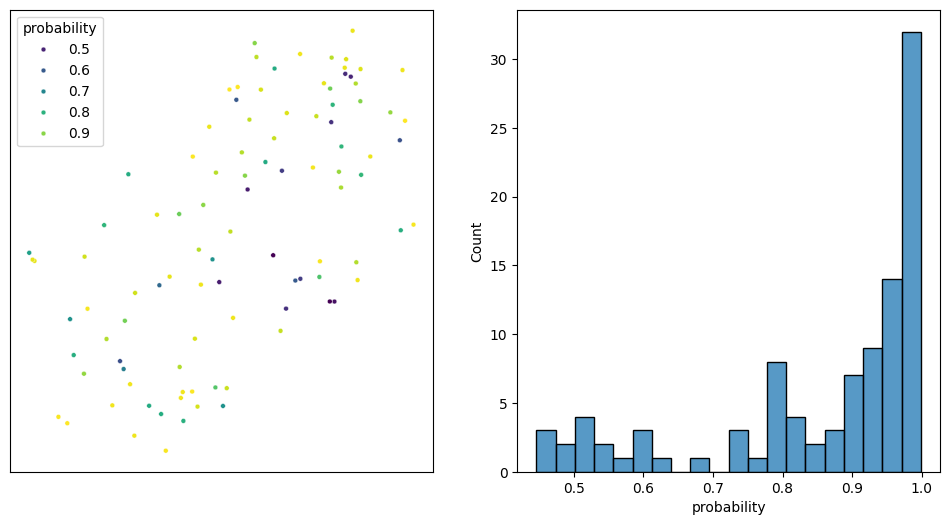

In [9]:
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = train_df.iloc[X_test.index][['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=X_test), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=12)
ax[0].set(xlabel=None) 
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)
fig.show()

As we might have expected from our TSNE plot, our model probabilities are sometimes low, because this is a hard problem.